#Dataset Setup

1. Download the dataset from:
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

2. Upload the dataset folder to Google Colab.

3. Ensure the folder structure is:

dataset/
   ├── Training
   └── Testing

4. Update the path if necessary.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = "/content/drive/MyDrive/dataset(brain_tumor)"
print(os.listdir(base_path))

Mounted at /content/drive
['Training', 'Testing']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    base_path + "/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = val_datagen.flow_from_directory(
    base_path + "/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    base_path + "/Testing",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 5047 images belonging to 4 classes.
Found 560 images belonging to 4 classes.
Found 1601 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_path = "/content/drive/MyDrive/brain_tumor_checkpoint.h5"

checkpoint_cb = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=False,   # save every epoch
    save_weights_only=False,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint_cb]
)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9220 - loss: 0.2108
Epoch 1: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 80s 507ms/step - accuracy: 0.9220 - loss: 0.2108 - val_accuracy: 0.8911 - val_loss: 0.3008
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9116 - loss: 0.2133
Epoch 2: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 513ms/step - accuracy: 0.9116 - loss: 0.2133 - val_accuracy: 0.8768 - val_loss: 0.3523
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9233 - loss: 0.1912
Epoch 3: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 77s 489ms/step - accuracy: 0.9233 - loss: 0.1912 - val_accuracy: 0.9071 - val_loss: 0.2390
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9330 - loss: 0.1781
Epoch 4: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 78s 497ms/step - accuracy: 0.9329 - loss: 0.1782 - val_accuracy: 0.9018 - val_loss: 0.2492
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9287 - loss: 0.1701
Epoch 5: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 78s 495ms/step - accuracy: 0.9308 - loss: 0.1904 - val_accuracy: 0.8964 - val_loss: 0.2475
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9241 - loss: 0.1921
Epoch 7: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 78s 496ms/step - accuracy: 0.9241 - loss: 0.1921 - val_accuracy: 0.9107 - val_loss: 0.2281
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9347 - loss: 0.1544
Epoch 8: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 79s 500ms/step - accuracy: 0.9347 - loss: 0.1545 - val_accuracy: 0.9107 - val_loss: 0.2352
Epoch 9/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9367 - loss: 0.1683
Epoch 9: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 79s 500ms/step - accuracy: 0.9368 - loss: 0.1682 - val_accuracy: 0.9196 - val_loss: 0.2141
Epoch 10/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9348 - loss: 0.1590
Epoch 10: saving model to /content/drive/MyDrive/brain_tumor_checkpoint.h5


158/158 ━━━━━━━━━━━━━━━━━━━━ 77s 489ms/step - accuracy: 0.9348 - loss: 0.1590 - val_accuracy: 0.8839 - val_loss: 0.3042


In [ ]:
model.save("/content/drive/MyDrive/brain_tumor_final_model.h5")
print("Final model saved!")

Final model saved!


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

51/51 ━━━━━━━━━━━━━━━━━━━━ 477s 10s/step - accuracy: 0.7708 - loss: 1.2609
Test Accuracy: 0.8575890064239502
Test Loss: 0.6794673204421997


In [ ]:
import numpy as np

# True labels
y_true = test_generator.classes

# Predicted probabilities
y_pred_probs = model.predict(test_generator)

# Predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions done!")

51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 226ms/step
Predictions done!


<Figure size 600x600 with 0 Axes>

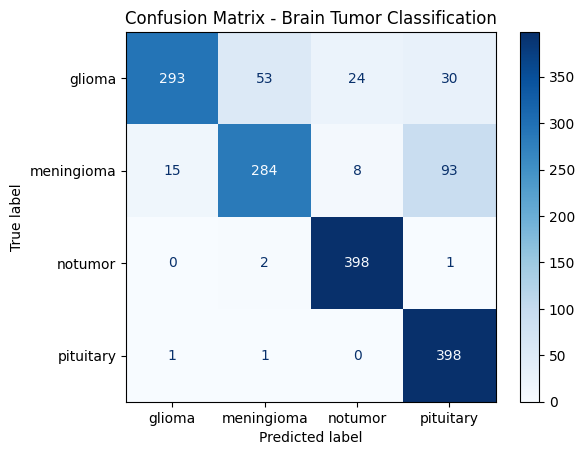

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Brain Tumor Classification")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.95      0.73      0.83       400
  meningioma       0.84      0.71      0.77       400
     notumor       0.93      0.99      0.96       401
   pituitary       0.76      0.99      0.86       400

    accuracy                           0.86      1601
   macro avg       0.87      0.86      0.85      1601
weighted avg       0.87      0.86      0.85      1601



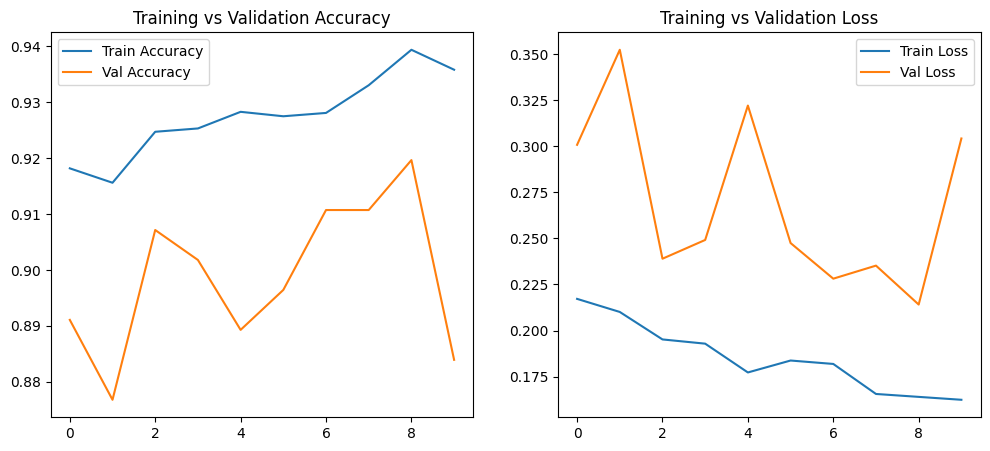

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()